In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

In [2]:
# Option A: Use VGG-Face if you have the weights file
# model = build_vgg_face()   # your original architecture
# model.load_weights('vgg_face_weights.h5')
# feature_extractor = Model(inputs=model.input, outputs=model.layers[-2].output)

# Option B: Use VGG16 (ImageNet) as feature extractor — simplest
base = VGG16(weights='imagenet', include_top=False, pooling='avg', input_shape=(224,224,3))
feature_extractor = base

In [3]:
DATASET_DIR = "Dataset"   # relative to the notebook location

In [4]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

DATASET_DIR = "."   # <-- images live next to this notebook

image_paths = []
embeddings = []
images_for_plot = []

for fname in sorted(os.listdir(DATASET_DIR)):
    if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
        continue
    path = os.path.join(DATASET_DIR, fname)
    try:
        img = load_img(path, target_size=(224, 224))
        arr = img_to_array(img) / 255.0
        emb = feature_extractor.predict(np.expand_dims(arr, 0), verbose=0)[0]
        embeddings.append(emb)
        image_paths.append(path)
        images_for_plot.append(img)
        print(f"OK: {fname}")
    except Exception as e:
        print(f"Error reading {fname}: {e}")

embeddings = np.array(embeddings)
print("Embeddings shape:", embeddings.shape)

OK: train_apple_image (262).png
OK: train_apple_image (263).png
OK: train_apple_image (264).png
OK: train_apple_image (265).png
OK: train_apple_image (266).png
OK: train_apple_image (267).png
OK: train_orange_image (250).png
OK: train_orange_image (251).png
OK: train_orange_image (252).png
OK: train_orange_image (253).png
OK: train_orange_image (254).png
Embeddings shape: (11, 512)


In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import numpy as np

# L2-normalize embeddings (important for appearance/face embeddings)
X = normalize(embeddings)

K = 2
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

print("Cluster counts:", np.bincount(labels))

Cluster counts: [7 4]


Cluster 0: 7 images


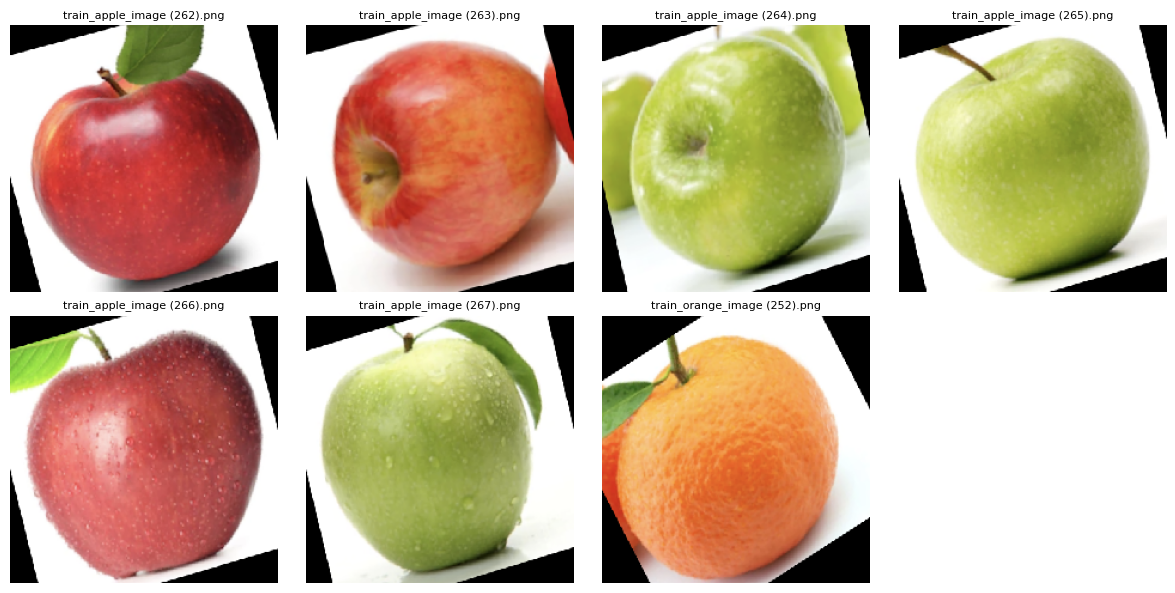

Cluster 1: 4 images


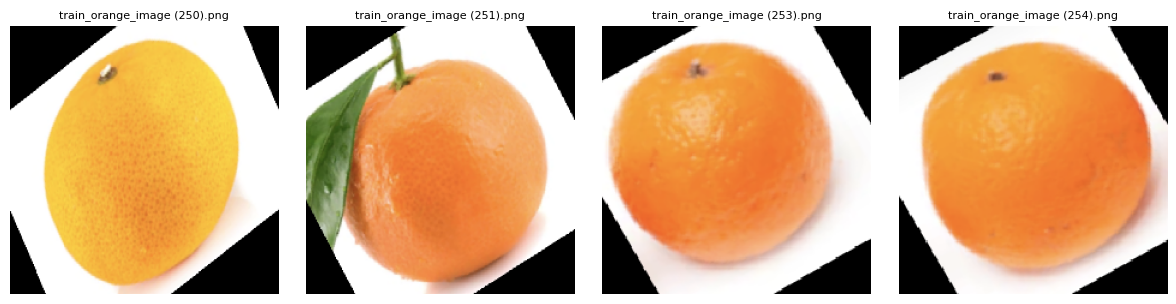

In [12]:
import matplotlib.pyplot as plt

def show_cluster(cluster_id, max_show=8):
    idxs = [i for i, l in enumerate(labels) if l == cluster_id]
    print(f"Cluster {cluster_id}: {len(idxs)} images")
    n = min(max_show, len(idxs))
    cols = 4
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(cols*3, rows*3))
    for v in range(n):
        plt.subplot(rows, cols, v+1)
        plt.imshow(images_for_plot[idxs[v]])
        plt.title(os.path.basename(image_paths[idxs[v]]), fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

for c in range(K):
    show_cluster(c, max_show=8)

In [13]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    sil = silhouette_score(X, km.labels_)
    print(f"k={k}  inertia={km.inertia_:8.1f}  silhouette={sil:.3f}")

k=2  inertia=     0.1  silhouette=0.143
k=3  inertia=     0.1  silhouette=0.154
k=4  inertia=     0.1  silhouette=0.140
k=5  inertia=     0.0  silhouette=0.140
k=6  inertia=     0.0  silhouette=0.134
k=7  inertia=     0.0  silhouette=0.117


In [14]:
import pandas as pd

df = pd.DataFrame({
    "filename": [os.path.basename(p) for p in image_paths],
    "cluster": labels
})
df.to_csv("cluster_assignments.csv", index=False)
print(df.head())
print("Counts:", df["cluster"].value_counts().to_dict())

                      filename  cluster
0  train_apple_image (262).png        0
1  train_apple_image (263).png        0
2  train_apple_image (264).png        0
3  train_apple_image (265).png        0
4  train_apple_image (266).png        0
Counts: {0: 7, 1: 4}


In [16]:
# Pairwise cosine similarity between embeddings
from sklearn.metrics.pairwise import cosine_similarity
sim = cosine_similarity(X)
print("Mean intra-set similarity:", sim[np.triu_indices_from(sim, k=1)].mean())

Mean intra-set similarity: 0.9871492
